In [1]:
import os
import sys
import json
import numpy as np
import re

sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used,split_by_musicianship,load_results_with_exclusion_no_dropping,refresh_unused_batch, update_sequences_after_qc, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability, estimate_split_half_reliability, compute_itemwise_split_half_reliability_by_isi
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_groupwise_item_response_scatter, plot_power_curve_sem, plot_itemwise_hit_fa_relationship

from utls.reliability import compute_power_curve
from utls.plotting import plot_power_curve, plot_dprime_by_isi#, plot_groupwise_item_response_scatter

import os, random
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict


from scipy.stats import norm
import pandas as pd

def compute_itemwise_dprime(df_hits, df_fas, eps=1e-5):
    # Ensure identical column sets
    common = sorted(set(df_hits.columns) & set(df_fas.columns))
    df_hits = df_hits[common]
    df_fas  = df_fas[common]

    hit_rates = df_hits.mean(axis=0).clip(eps, 1-eps)
    fa_rates  = df_fas.mean(axis=0).clip(eps, 1-eps)

    # Force pandas Series output
    dprime_values = norm.ppf(hit_rates.values) - norm.ppf(fa_rates.values)
    return pd.Series(dprime_values, index=common)

def compute_dprime_for_subjects(df, subject_list):
    """
    Returns ISIs and d' curve for a selected subset of subjects.
    """
    df_sub = df[df["subject"].isin(subject_list)]
    return compute_dprime_curve(df_sub)

def split_half_reliability(df, n_splits=1000, seed=0, method="pearson"):
    """
    df: per-subject-per-ISI dataframe (with hit_rate + fa_rate)
    n_splits: number of random half-splits
    method: pearson or spearman
    
    Returns dict with:
        correlations: list of correlations across splits
        mean_r: mean reliability
        ci: 95% bootstrap CI
    """

    rng = np.random.default_rng(seed)
    df = df[df["isi"] != -1].copy()
    subjects = df["subject"].unique()
    n = len(subjects)

    correlations = []

    for _ in range(n_splits):
        # random split
        rng.shuffle(subjects)
        half1 = subjects[: n//2]
        half2 = subjects[n//2 :]

        # compute d' for each split
        isis1, d1 = compute_dprime_for_subjects(df, half1)
        isis2, d2 = compute_dprime_for_subjects(df, half2)

        # ensure ISIs match exactly
        assert np.all(isis1 == isis2)

        # pick correlation type
        if method == "pearson":
            r = np.corrcoef(d1, d2)[0, 1]
        else:
            from scipy.stats import spearmanr
            r = spearmanr(d1, d2).correlation

        correlations.append(r) 

    correlations = np.array(correlations)
    ci = np.percentile(correlations, [2.5, 97.5])

    # Spearman–Brown correction (optional):
    # corrected = 2*mean_r / (1 + mean_r)
    # include if needed

    return {
        "correlations": correlations,
        "mean_r": correlations.mean(),
        "ci": ci,
        "raw": correlations
    }

def power_analysis(df, 
                   min_n=6, 
                   max_n=None, 
                   n_repeats=300, 
                   seed=0, 
                   method="pearson"):
    """
    Compute how split-half reliability increases with number of participants.

    Parameters
    ----------
    df : DataFrame (subject x ISI summary rows)
    min_n : smallest N of subjects to test
    max_n : largest N to test (defaults to all participants)
    n_repeats : bootstrap repetitions per N
    method : pearson or spearman

    Returns
    -------
    dict containing:
        Ns : array of sample sizes tested
        r_mean : mean reliability per N
        r_ci_low, r_ci_high : 95% CIs
        r_mat : full matrix (n_Ns x n_repeats)
    """
    df = df[df["isi"] != -1].copy()
    rng = np.random.default_rng(seed)
    subjects = np.array(df["subject"].unique())
    total_subj = len(subjects)

    if max_n is None:
        max_n = total_subj

    Ns = np.arange(min_n, max_n + 1)
    
    # storage
    r_mat = np.zeros((len(Ns), n_repeats))

    for idx, N in enumerate(Ns):
        for k in range(n_repeats):
            # sample N participants without replacement
            chosen = rng.choice(subjects, size=N, replace=False)

            # split into halves
            rng.shuffle(chosen)
            half1 = chosen[: N//2]
            half2 = chosen[N//2 :]

            # compute curves
            isis1, d1 = compute_dprime_for_subjects(df, half1)
            isis2, d2 = compute_dprime_for_subjects(df, half2)

            # remove NaNs and constant vectors
            valid = ~(np.isnan(d1) | np.isnan(d2))
            d1v, d2v = d1[valid], d2[valid]
            if len(d1v) < 2 or np.std(d1v) == 0 or np.std(d2v) == 0:
                r = np.nan
            else:
                if method == "pearson":
                    r = np.corrcoef(d1v, d2v)[0,1]
                else:
                    from scipy.stats import spearmanr
                    r = spearmanr(d1v, d2v).correlation

            r_mat[idx, k] = r

    # compute summary
    r_mean = np.nanmean(r_mat, axis=1)
    r_ci_low = np.nanpercentile(r_mat, 2.5, axis=1)
    r_ci_high = np.nanpercentile(r_mat, 97.5, axis=1)

    return {
        "Ns": Ns,
        "r_mean": r_mean,
        "r_ci_low": r_ci_low,
        "r_ci_high": r_ci_high,
        "r_mat": r_mat
    }

def _clip(p, eps=1e-5):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()

def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)

def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def _clip(p, eps=1e-2):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()


def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)


def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

# ============================================
# Bootstrapping
# ============================================

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def p_to_star(p):
    if p < 1e-4: return f"**** p={p:.3f}"
    if p < 1e-3: return f"*** p={p:.3f}"
    if p < 0.01: return f"** p={p:.3f}"
    if p < 0.05: return f"* p={p:.3f}"
    return f"n.s. p={p:.3f}"

def run_analysis(df, n_boot=5000):
    # Remove unwanted ISI
    df_removed = df[df["isi"] != -1].copy()
    isis, dp = compute_dprime_curve(df_removed)
    boot = bootstrap_dprime(df_removed, n_boot=n_boot)
    N = df_removed["subject"].nunique()

    hrs = compute_population_hit_rates_by_isi(df)
    fa  = compute_population_fa_rate(df)
    return {
        "isis": isis,
        "dprime": dp,
        "boot": boot,
        "hrs": hrs,
        "fa": fa,
        "N": N
    }

In [2]:
# results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# results = list(results)

batch_size = 8
active_batch_size = batch_size*18


tasks = ["env-sounds" ,"glob-music", "atexts", "nhs-region-len120"]
which_task = tasks[0] # "global-music-len120", "atexts-len120" "nhs-region-len120"
base_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/len120_multi/"
seqs_paths = {"env-sounds": "mem_exp_ind-nature_2025", 
              "glob-music": "global-music-2025-n_80",
              "atexts": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"env-sounds": "Industrial and Nature", 
              "glob-music": "Globalized Music",
              "atexts": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}

exps, seqs, fnames, skipped_exps, skipped_seqs, skipped_fnames = load_results_with_exclusion_no_dropping(f"/mindhive/mcdermott/www/bjmedina/experiments/{which_task}/results/{which_task}/len120_multi",
                                                    min_dprime=2,
                                                    min_trials=120,
                                                    skip_len60=True,
                                                    verbose=False,
                                                    return_skipped=True)


# ---- group indices by sequence ----
seq_to_indices = defaultdict(list)
for i, s in enumerate(seqs):
    seq_to_indices[s].append(i)

# ---- randomly keep one index per sequence ----
keep = [random.choice(idxs) for idxs in seq_to_indices.values()]

# ---- apply filter ----
exps   = [exps[i]   for i in keep]
seqs   = [seqs[i]   for i in keep]
fnames = [fnames[i] for i in keep]

print(base_path.format(seqs_paths[which_task]))

move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)

good = set(seqs)
skipped_seqs = [s for s in skipped_seqs if s not in good]

seqs_good = seqs          # Passed d' threshold
seqs_bad  = skipped_seqs  # Failed d' threshold


info = update_sequences_after_qc(
    seq_dir=base_path.format(seqs_paths[which_task]),
    seqs_good=seqs_good,
    seqs_bad=seqs_bad
)
print(base_path.format(seqs_paths[which_task]))
current_batch = refresh_unused_batch(base_path.format(seqs_paths[which_task]), active_batch_size)

print("Number of participants used in analysis:", len(exps))
print("New active batch:", current_batch, "of size ", len(current_batch))


safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/figures/human-results/multi-isi", safe_name)

ensure_dir(save_dir)

# ---- extract seq numbers ----
seqnums = [int(re.search(r"seq(\d+)", s).group(1)) for s in seqs]

# ---- group seqnums by batch ----
batch_to_seqnums = defaultdict(set)
for n in seqnums:
    batch_id = (n - 1) // batch_size
    batch_to_seqnums[batch_id].add(n)

# ---- determine which batches are complete ----
complete_batches = {
    b for b, nums in batch_to_seqnums.items()
    if nums == set(range(b * batch_size + 1, b * batch_size + batch_size + 1))
}

# ---- filter everything in lockstep ----
keep = [
    i for i, n in enumerate(seqnums)
    if (n - 1) // batch_size in complete_batches
]

exps   = [exps[i] for i in keep]
seqs   = [seqs[i] for i in keep]
fnames = [fnames[i] for i in keep]

print("Kept batches:", sorted(complete_batches))
print("N kept:", len(seqs))

experienced, beginner = split_by_musicianship(exps)
print(len(experienced), len(beginner))

/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi/
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi/
Number of participants used in analysis: 252
New active batch: ['seq065_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq094_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq105_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq122_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq128_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq132_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq134_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq135_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq141_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json', 'seq143_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json'] of size  10
Directory already exists: /orcd/data/jhm/001

In [3]:
x = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, 1,2,4,8,16,32,64]
x_filtered = x[x['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);

x_experienced = recompute_dprime_by_isi_per_subject(experienced)
# Assuming `x` is your DataFrame
x_experienced = x_experienced[x_experienced['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x_experienced.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);

x_beginner = recompute_dprime_by_isi_per_subject(beginner)
# Assuming `x` is your DataFrame
x_beginner = x_beginner[x_beginner['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x_beginner.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm

out = run_analysis(x)
out_beginner = run_analysis(x_beginner)
out_experienced = run_analysis(x_experienced)

In [5]:
from scipy.stats import ttest_rel

# Filter unwanted ISIs
xf = x[x["isi"] != -1].copy()

# Extract aligned subject-level d'
dp16 = xf[xf["isi"] == 16].set_index("subject")["d_prime"]
dp64 = xf[xf["isi"] == 64].set_index("subject")["d_prime"]

# Align subjects
paired = pd.concat([dp16, dp64], axis=1, keys=["dp16", "dp64"]).dropna()

# Paired t-test
tval, pval = ttest_rel(paired["dp16"], paired["dp64"])

print("Paired t-test ISI=16 vs ISI=64:")
print(f"t = {tval:.3f}, p = {pval:.4g}")
print(f"N paired = {paired.shape[0]}")

Paired t-test ISI=16 vs ISI=64:
t = 4.376, p = 3.106e-05
N paired = 96


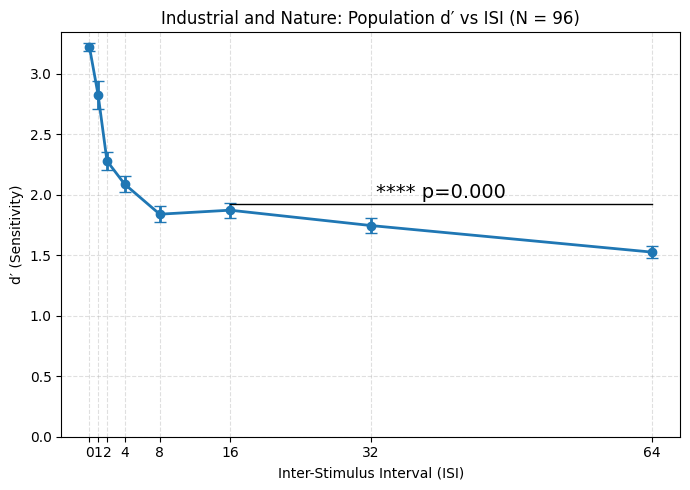

In [6]:
isis = out["isis"]
dprime = out["dprime"]
boot = out["boot"]

plt.figure(figsize=(7,5))
plt.errorbar(
    isis,
    dprime,
    yerr=boot["sem"],
    fmt='o-',
    capsize=4,
    linewidth=2,
    markersize=6
)

# Find the y-position slightly above both points
y_max = max(dprime[list(isis).index(16)], dprime[list(isis).index(64)])
y_sig = y_max + 0.05  # adjust as needed


sig = p_to_star(pval)
# x positions of the two ISIs
x1 = list(isis).index(16)
x2 = list(isis).index(64)

ax = plt.gca()

ax.plot([16, 64], [y_sig, y_sig], color='black', linewidth=1)
ax.text(
    (16 + 64) / 2,
    y_sig + 0.02,
    sig,
    ha='center',
    va='bottom',
    fontsize=14
)

isi_plot_dir = os.path.join(save_dir, "dprime-vs-isi.png")


plt.xticks(isis, isis)
plt.ylim(bottom=0)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("d′ (Sensitivity)")
plt.title(f"{hr_task_name[which_task]}: Population d′ vs ISI (N = {out['N']})")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(isi_plot_dir)
plt.show()

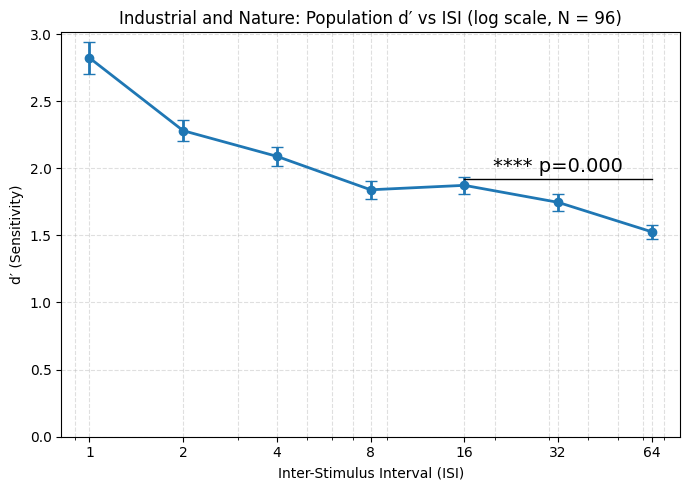

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

isis = np.array(out["isis"])
dprime = np.array(out["dprime"])
sem = np.array(boot["sem"])

# ---- remove ISI = 0 ----
mask = isis > 0
isis_log = isis[mask]
dprime_log = dprime[mask]
sem_log = sem[mask]

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    isis_log,
    dprime_log,
    yerr=sem_log,
    fmt='o-',
    capsize=4,
    linewidth=2,
    markersize=6
)

ax.set_xscale("log")
ax.set_xticks(isis_log)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())

# ---- significance bar (16 vs 64 still valid) ----
y_max = max(
    dprime_log[list(isis_log).index(16)],
    dprime_log[list(isis_log).index(64)]
)
y_sig = y_max + 0.05

sig = p_to_star(pval)

ax.plot([16, 64], [y_sig, y_sig], color='black', linewidth=1)
ax.text(
    (16 * 64) ** 0.5,
    y_sig + 0.02,
    sig,
    ha='center',
    va='bottom',
    fontsize=14
)

ax.set_ylim(bottom=0)
ax.set_xlabel("Inter-Stimulus Interval (ISI)")
ax.set_ylabel("d′ (Sensitivity)")
ax.set_title(f"{hr_task_name[which_task]}: Population d′ vs ISI (log scale, N = {out['N']})")
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dprime-vs-isi-log.png"))
plt.show()

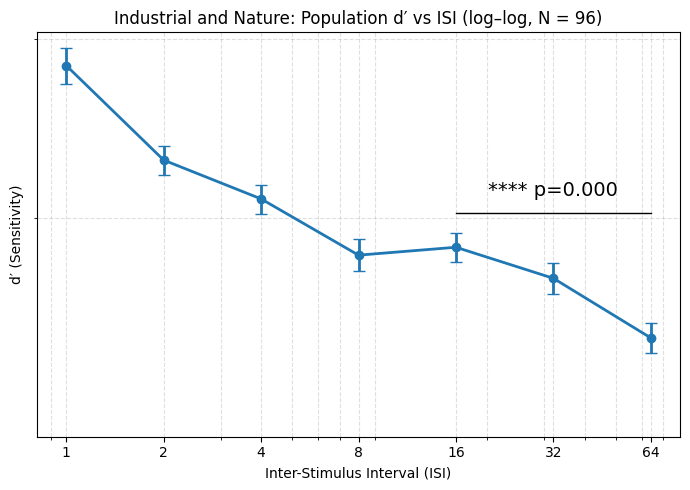

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

isis = np.array(out["isis"])
dprime = np.array(out["dprime"])
sem = np.array(boot["sem"])

# ---- exclude ISI = 0 ----
mask = isis > 0
isis = isis[mask]
dprime = dprime[mask]
sem = sem[mask]

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    isis,
    dprime,
    yerr=sem,
    fmt='o-',
    capsize=4,
    linewidth=2,
    markersize=6
)

# ---- log scales ----
ax.set_xscale("log")
ax.set_yscale("log")

# ---- clean ticks ----
ax.set_xticks(isis)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())

ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_minor_formatter(plt.NullFormatter())

# ---- significance bar (16 vs 64) ----
i16 = list(isis).index(16)
i64 = list(isis).index(64)

y_max = max(dprime[i16], dprime[i64])
y_sig = y_max * 1.08   # multiplicative offset for log scale

sig = p_to_star(pval)

ax.plot([16, 64], [y_sig, y_sig], color='black', linewidth=1)
ax.text(
    (16 * 64) ** 0.5,   # geometric mean (log-centered)
    y_sig * 1.03,
    sig,
    ha='center',
    va='bottom',
    fontsize=14
)

# ---- labels & aesthetics ----
ax.set_ylim(bottom=dprime.min() * 0.8)
ax.set_xlabel("Inter-Stimulus Interval (ISI)")
ax.set_ylabel("d′ (Sensitivity)")
ax.set_title(
    f"{hr_task_name[which_task]}: Population d′ vs ISI (log–log, N = {out['N']})"
)
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dprime-vs-isi-loglog.png"))
plt.show()

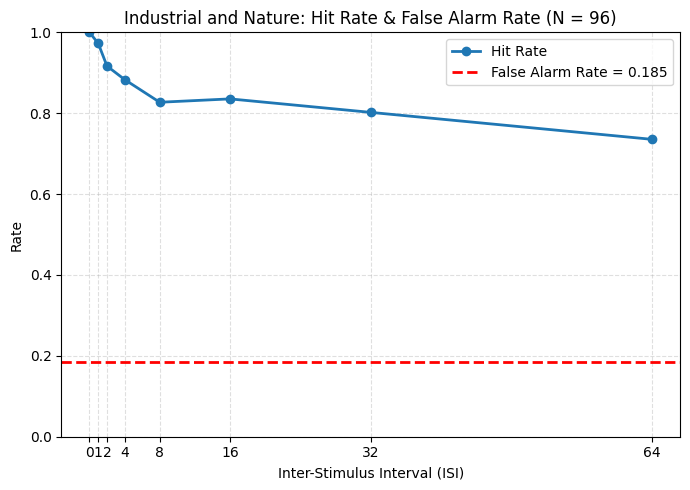

In [9]:
hrs = out["hrs"][1:]                     # dict: {ISI: hit_rate}
isis = np.array(list(hrs.keys()))
hit_rates = np.array([hrs[k] for k in isis])
fa_rate = out["fa"]                  # scalar
N = out["N"]

plt.figure(figsize=(7,5))

# ---- hit rate vs ISI ----
plt.plot(
    isis,
    hit_rates,
    'o-',
    linewidth=2,
    markersize=6,
    label="Hit Rate"
)

# ---- false alarm rate line ----
plt.axhline(
    y=fa_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"False Alarm Rate = {fa_rate:.3f}"
)

# ---- aesthetic controls ----
plt.xticks(isis, isis)
plt.ylim(0, 1)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("Rate")
plt.title(f"{hr_task_name[which_task]}: Hit Rate & False Alarm Rate (N = {N})")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()

plt.tight_layout()

hr_plot_dir = os.path.join(save_dir, "hit-rate_and_fa.png")
plt.savefig(hr_plot_dir)
plt.show()

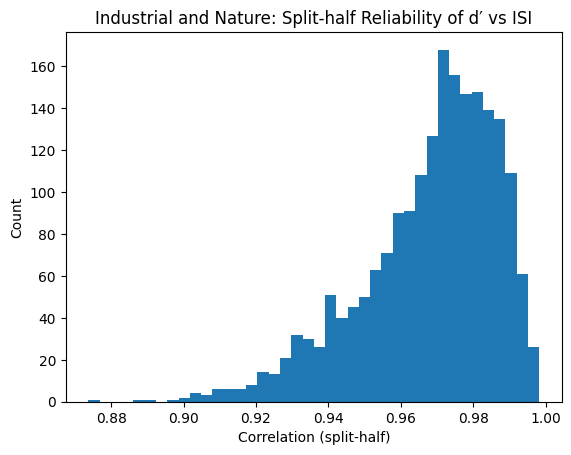

In [10]:
dp_cons_plot_dir = os.path.join(save_dir, "dprime-consistency.png")
rel = split_half_reliability(x, n_splits=2000, method="pearson")
# print("Mean split-half reliability:", rel["mean_r"])
# print("95% CI:", rel["ci"])

plt.hist(rel["correlations"], bins=40)
plt.xlabel("Correlation (split-half)")
plt.ylabel("Count")
plt.title(f"{hr_task_name[which_task]}: Split-half Reliability of d′ vs ISI")
plt.savefig(dp_cons_plot_dir)
plt.show()

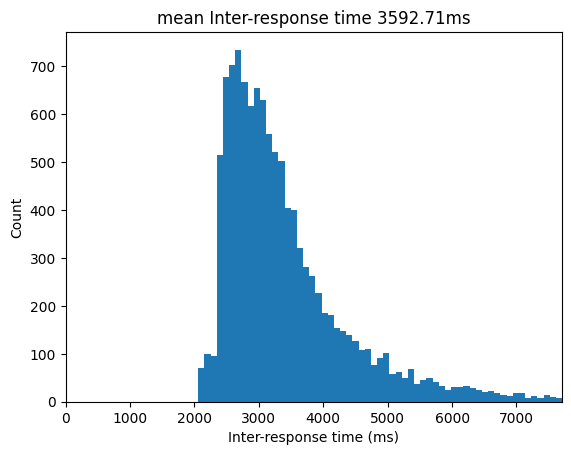

In [11]:
import numpy as np

absolute_isis = []

for exp in exps:
    time_elapsed = np.array(exp["time_elapsed"], dtype=float)  # ms
    
    # response-to-response intervals (ms)
    r2r = np.diff(time_elapsed)
    absolute_isis.extend(r2r)


plt.figure()
plt.hist(absolute_isis, bins=1000)
plt.xlabel("Inter-response time (ms)")
plt.ylabel("Count")
plt.xlim([0,np.mean(absolute_isis)+np.std(absolute_isis)*2])
plt.title(f"mean Inter-response time {np.mean(absolute_isis):.2f}ms")

plt.show()

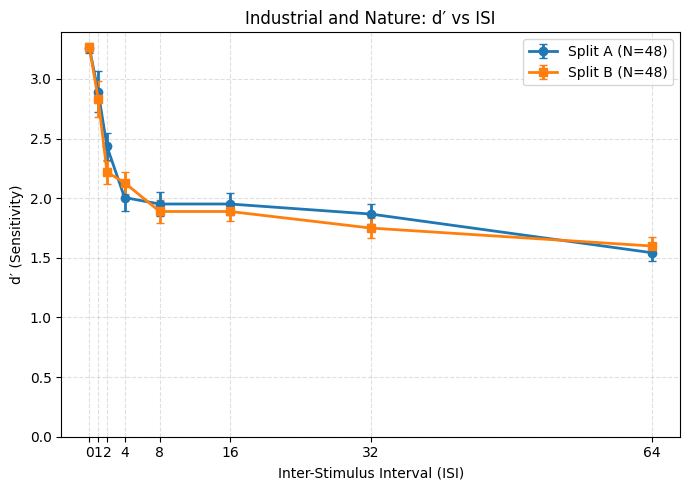

In [14]:
import numpy as np

subjects = x["subject"].unique()
np.random.seed(0)    # for reproducibility
np.random.shuffle(subjects)

half = len(subjects) // 2
subA = subjects[:half]
subB = subjects[half:]

xA = x[x["subject"].isin(subA)].copy()
xB = x[x["subject"].isin(subB)].copy()

outA = run_analysis(xA)
outB = run_analysis(xB)

plt.figure(figsize=(7,5))

# ---- Split A ----
plt.errorbar(
    outA["isis"],
    outA["dprime"],
    yerr=outA["boot"]["sem"],
    fmt='o-',
    capsize=3,
    linewidth=2,
    markersize=6,
    label=f"Split A (N={outA['N']})"
)

# ---- Split B ----
plt.errorbar(
    outB["isis"],
    outB["dprime"],
    yerr=outB["boot"]["sem"],
    fmt='s-',
    capsize=3,
    linewidth=2,
    markersize=6,
    label=f"Split B (N={outB['N']})"
)
isi_random_plot_dir = os.path.join(save_dir, "dprime-vs-isi_random-split.png")

plt.xticks(outA["isis"], outA["isis"])
plt.ylim(bottom=0)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("d′ (Sensitivity)")
plt.title(f"{hr_task_name[which_task]}: d′ vs ISI")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(isi_random_plot_dir)
plt.show()


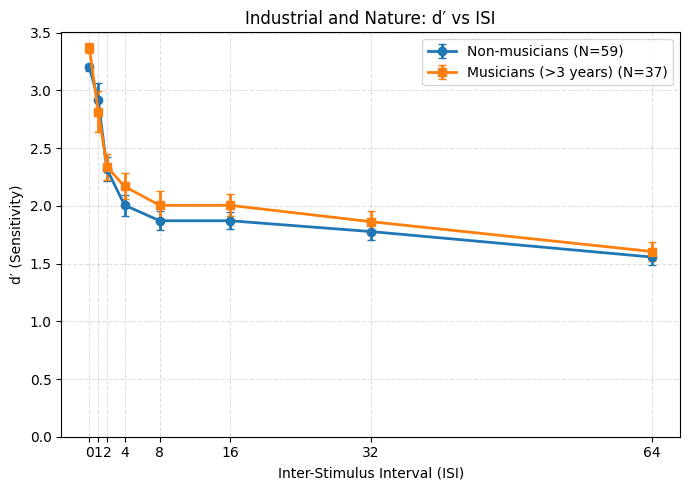

In [15]:
import numpy as np

plt.figure(figsize=(7,5))

# ---- Split A ----
plt.errorbar(
    out_beginner["isis"],
    out_beginner["dprime"],
    yerr=out_beginner["boot"]["sem"],
    fmt='o-',
    capsize=3,
    linewidth=2,
    markersize=6,
    label=f"Non-musicians (N={out_beginner['N']})"
)

# ---- Split B ----
plt.errorbar(
    out_experienced["isis"],
    out_experienced["dprime"],
    yerr=out_experienced["boot"]["sem"],
    fmt='s-',
    capsize=3,
    linewidth=2,
    markersize=6,
    label=f"Musicians (>3 years) (N={out_experienced['N']})"
)
isi_musician_plot_dir = os.path.join(save_dir, "dprime-vs-isi_musician_split.png")

plt.xticks(out_experienced["isis"], out_experienced["isis"])
plt.ylim(bottom=0)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("d′ (Sensitivity)")
plt.title(f"{hr_task_name[which_task]}: d′ vs ISI")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(isi_musician_plot_dir)
plt.show()


In [16]:
from collections import defaultdict

freq_dict = defaultdict(int)
for exp in exps:
    for i in exp.index:
        if exp.loc[i].isi == 16:
            current_stim = exp.loc[i].stimulus.split("/")[-1]
            freq_dict[current_stim] += 1

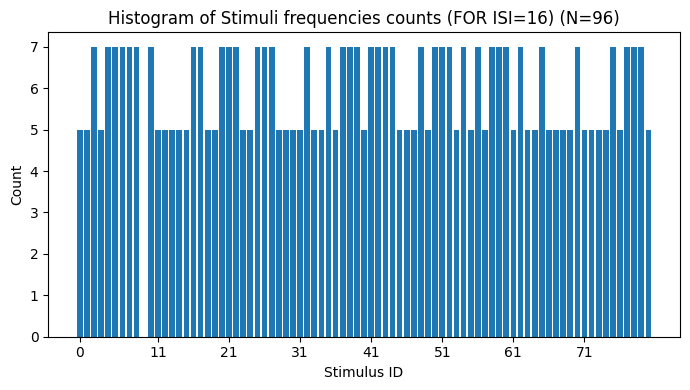

In [17]:
import re

freq_dict = defaultdict(int)
for exp in exps:
    for i in exp.index:
        if exp.loc[i].isi == 16:
            current_stim = exp.loc[i].stimulus.split("/")[-1]
            freq_dict[current_stim] += 1
            
# --- extract integers ---
stim_ids = []
counts = []

for k, v in freq_dict.items():
    n = int(re.findall(r"\d+", k)[-1])  # extract final integer
    stim_ids.append(n)
    counts.append(v)

# --- sort by stim id ---
stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# --- bar plot ---
plt.figure(figsize=(7,4))
plt.bar(stim_ids, counts)
plt.xlabel("Stimulus ID")
plt.ylabel("Count")
plt.xticks(stim_ids[::10])
plt.title(f"Histogram of Stimuli frequencies counts (FOR ISI={16}) (N={N})")
plt.tight_layout()
plt.show()

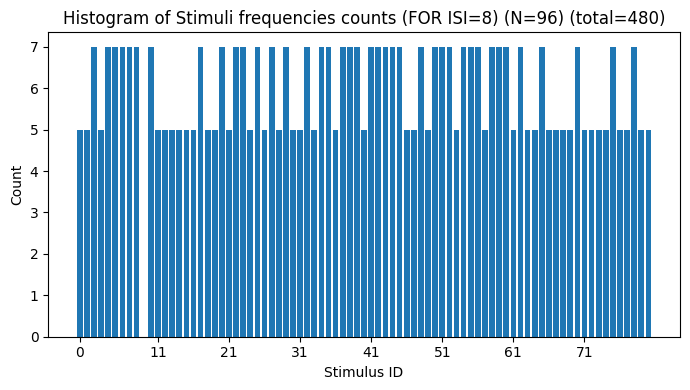

In [18]:
freq_dict = defaultdict(int)
isi_choice =8
for exp in exps:
    for i in exp.index:
        if exp.loc[i].isi == isi_choice:
            current_stim = exp.loc[i].stimulus.split("/")[-1]
            freq_dict[current_stim] += 1

# --- extract integers ---
stim_ids = []
counts = []

for k, v in freq_dict.items():
    n = int(re.findall(r"\d+", k)[-1])  # extract final integer
    stim_ids.append(n)
    counts.append(v)

# --- sort by stim id ---
stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# --- bar plot ---
plt.figure(figsize=(7,4))
plt.bar(stim_ids, counts)
plt.xlabel("Stimulus ID")
plt.ylabel("Count")
plt.xticks(stim_ids[::10])
plt.title(f"Histogram of Stimuli frequencies counts (FOR ISI={isi_choice}) (N={N}) (total={np.sum(counts)})")
plt.tight_layout()
plt.show()

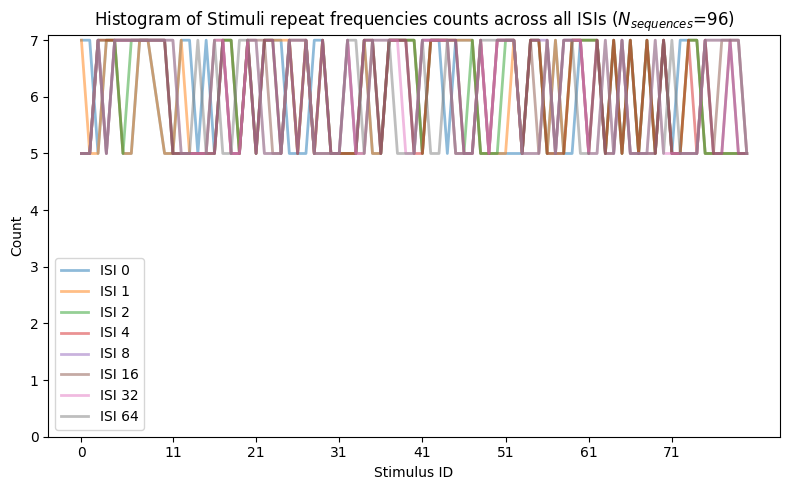

In [19]:
plt.figure(figsize=(8,5))

freq_dict_isi = defaultdict(dict)
all_possible_ids = set()

# Collect all stim IDs first
for exp in exps:
    for i in exp.index:
        current_stim = exp.loc[i].stimulus.split("/")[-1]
        sid = int(re.findall(r"\d+", current_stim)[-1])
        all_possible_ids.add(sid)

all_possible_ids = np.array(sorted(all_possible_ids))

for j in [0,1,2,4,8,16,32,64]:

    # count frequencies
    freq_dict = defaultdict(int)
    for exp in exps:
        for i in exp.index:
            if exp.loc[i].isi == j:
                current_stim = exp.loc[i].stimulus.split("/")[-1]
                sid = int(re.findall(r"\d+", current_stim)[-1])
                freq_dict[sid] += 1

    freq_dict_isi[j] = freq_dict

    # fill vector over full range
    counts = np.array([freq_dict[sid] for sid in all_possible_ids])

    # plot curve
    plt.plot(all_possible_ids, counts, label=f"ISI {j}", linewidth=2, alpha=0.5)

plt.legend()
plt.xlabel("Stimulus ID")
plt.ylabel("Count")
plt.ylim(bottom=0)
plt.xticks(all_possible_ids[::10])
plt.title(f"Histogram of Stimuli repeat frequencies counts across all ISIs ($N_{{sequences}}$={N})")
plt.tight_layout()
plt.show()


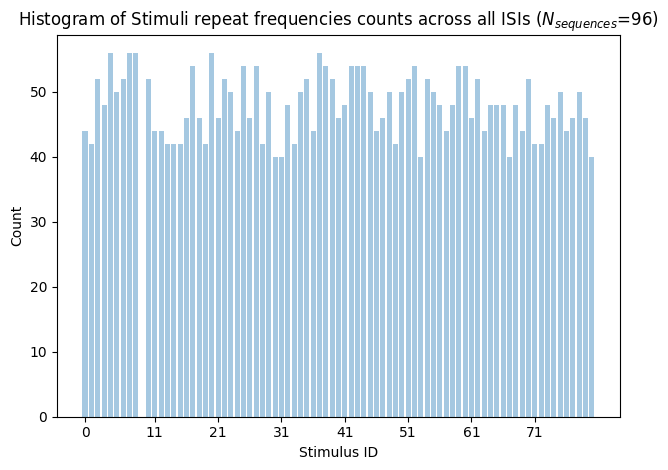

In [20]:
stim_dict = defaultdict(int)

for isi in freq_dict_isi:
    freq_dict = freq_dict_isi[isi]

    for stim in freq_dict:
       stim_dict[stim]+= freq_dict[stim]


# --- extract integers ---
stim_ids = []
counts = []

for k, v in stim_dict.items():
    stim_ids.append(k)
    counts.append(v)

# --- sort by stim id ---
stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# --- bar plot ---
plt.bar(stim_ids, counts, alpha=0.4)

plt.xlabel("Stimulus ID")
plt.ylabel("Count")
plt.xticks(stim_ids[::10])
plt.title(f"Histogram of Stimuli repeat frequencies counts across all ISIs ($N_{"{sequences}"}$={N})")
plt.tight_layout()
plt.show()